# INFEWS Farm Model

## Objective and Prerequisites

This model is based of the example of a stochastic optimization problem from [Gurobi](https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/). That problem asked you to consider a situation where you have to buy today the stock of products to sell tomorrow but you don't know the exact demand you will see. Then you will have to decide what to do with whatever is left which includes selling it for scrap. This is called the Newspaper Vendor Problem. 


---
## Problem Description

For our problem a farm must decide how to prepare for different climate futures. Each climate future has different precipation patterns that will affect how much irrigation water is needed for different plants. Our farm must decide if and how much alternative water and electricity to invest in. Using a combination of precipation, alternative water, and irrigation water the decision makers maximizes profit where revenue is based on the price of the crop and the yield available and the costs are the costs of investing in alternative water and buying irrigation water. There are known costs associated with buying irrigation water, investing in alternative water, but the unknown is knowing how much water will be available as rain.

Our model has three indicies related to climate, season, and option. 

The climate index has to do with what the possible climate futures. In this model there are 3 climate futures.


| Climate | Description |
| --- | --- |
| C1 |  DFW Historical Precipitation |
| C2 |  Lubbock Historical Precipitation |
| C3 |  San Angelo Historical Precipitation |

The season index has to do with the number of growing seasons. In this model there are 5 growing seasons.

| Season | Description |
| --- | --- |
| S1 | Growing Season 1 that correlates with the first year |
| S2 | Growing Season 2 that correlates with the second year |
| S3 | Growing Season 3 that correlates with the third year |
| S4 | Growing Season 4 that correlates with the fourth year |
| S5 | Growing Season 5 that correlates with the fifth year |

The option index correlates to the possible precipatation values in each climate scenario. There are 5 options in each climate scenario

| Season | Description |
| --- | --- |
| O1 | Option 1 that correlates with a possible realization for a given climate scenario |
| O2 | Option 2 that correlates with a possible realization for a given climate scenario |
| O3 | Option 3 that correlates with a possible realization for a given climate scenario |
| O4 | Option 4 that correlates with a possible realization for a given climate scenario |
| O5 | Option 5 that correlates with a possible realization for a given climate scenario |



---
## Model Formulation

### Sets and Indices

$k \in \text{Climate}=\{\text{C1}, \text{C2}, \text{C3}\}$

$i \in \text{Season}=\{\text{S1}, \text{S2}, \text{S3}, \text{S4}, \text{S5}\}$

$j \in \text{Option}=\{\text{O1}, \text{O2}, \text{O3}, \text{O4}, \text{O5}\}$

$\text{Sets} = \text{Climate} \cup \text{Season} \cup \text{Option}$

### Parameters

$\text{alt_water}_{k} \in \mathbb{R}^+$: The amount of alternative water for climate scenario $k$

$\text{ha} \in \mathbb{R}^+$: Hectacres

$\text{price} \in \mathbb{R}^+$: Price of crop in tons

$\text{cost alt water} \in \mathbb{R}^+$: Cost of alternative water

$\text{salt concentration water} \in \mathbb{R}^+$: The salt concentration of water

$\text{salt concentration} \in \mathbb{R}^+$: The salt concentration of soil

$\text{alt water} \in \mathbb{R}^+$: The salt concentration of water





### Decision Variables

$\text{water}_{k,i,j} \in \mathbb{N}^+$: How much water to use for climate $k$, during season $i$, and option $j$. 

$\text{irrigation_water}_{k,i,j} \in \mathbb{N}^+$: How much irrigation water to buy for climate $k$, during season $i$, and option $j$. 

$\text{climate_choice} \in \mathbb{N}^+$:Which climate option do you choose

$\text{crop_yield}_{k,i,j} \in \mathbb{N}^+$: The yield based on the amount of water used in climate $k$, during season $i$, and option $j$. 


### Objective Function

- **Cost**: Minimize total shipping costs.

\begin{equation}
\text{Maximize} \quad Z = \sum_{(k,i,j) \in \text{Sets} \times \text{Sets}}
{\text{crop_yield}_{k,i,j} \times \text{ha} \times \text{price} - 
\text{alt_water}_{k} \times \text{cost_alt_water} \times \text{climate_choice}_{k} -
\text{irrigation_water}_{k,i,j} \times \text{cost_irrigation_water} }
\end{equation}

### Constraints

- **Water Used**: Water used must be less than or equal to the sum of the rain, irrigation, and alternative water.

\begin{equation}
\text{rain}_{k,i,j} + \text{climate_choice}_{k} \times \text{alt_water}_{k} + \text{irrigation_water}_{k,i,j} \geq \text{water}_{k,i,j} 
\quad \forall k \in \text{Climate} \quad \forall i \in \text{Season} \quad \forall j \in \text{Option}
\end{equation}

- **Crop Yield**: Crop yield is based on a production function based on water depth .

\begin{equation}
\sum_{s \in \text{Sets}}{\text{crop_yield}_{k,i,j} \leq -3.35 + 0.2064 \times \text{water}_{k,i,j} - 0.0014 \times \text{water}_{k,i,j}^2 + 2.326 \times \text{salt_conc_water}^2 - 2.031 \times \text{salt_conc} + 2.326 \times \text{salt_conc}^2 } - 0.071 \times \text{water}_{k,i,j} \times \text{salt_conc_water} + 0.033 \times \text{water}_{k,i,j} \times \text{salt_conc}  
\quad \forall k \in \text{Climate} \quad \forall i \in \text{Season} \quad \forall j \in \text{Option}
\end{equation}


- **Climate Choice**: Must choose one climate choice

\begin{equation}
\sum_{k \in Climate} {\text{Climate}_{k} } = 1
\end{equation}

---
## Python Implementation

We import the Gurobi Python Module and other Python libraries.

Import Libraries, Helpful Links, and Making Sure all Results show after each chunk.

In [1]:
from gurobipy import * 
import gurobipy as gp
import random
random.seed(a=100)
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import gridspec
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import scipy.stats as scs

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Problem Source: https://www.gurobi.com/resource/solving-simple-stochastic-optimization-problems-with-gurobi/
# Matplotlib documentation: https://matplotlib.org/tutorials/introductory/pyplot.html
# Pandas documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html

In [2]:
# CSV improts

rain_c0_df = pd.read_csv('precips_c0.csv', index_col=0)

rain_c0_dict = rain_c0_df.set_index(['run','year']).T.to_dict('records')

rain_c0_dict = rain_c0_dict[0]

rain_c1_df = pd.read_csv('precips_c1.csv', index_col=0)

rain_c1_dict = rain_c1_df.set_index(['run','year']).T.to_dict('records')

rain_dict = rain_c1_dict[0]



Some helpful conversions.
And some parameterization and upper and lower bounds.

In [3]:
# Conversions

cm2_ha = 100000000 # 100,000,000 cm2 = 1 ha

cm3_gal = 3785.41 # 3785.41 cm2 = 1 Gal

m3_kGal = 3.785411784

gal_acre_ft = 325851 # 1 acre ft = 325851 gallons

acre_ha = 2.47105 # 1 hectare = 2.47105 acres

cm_ft = 30.48 # 1 ft = 30.48 cm

cm_in = 2.54

lb_tonne = 2204.62

# Hours in a Month
hrs_month = 720

#Days in Month
days_month = 30

#Growing Season Months
gs_months = 9

# Parameters

ha = 200 # hectares average size of texas farms 411 acres rounded up, https://www.texasagriculture.gov/About/TexasAgStats.aspx#:~:text=For%2036%25%20of%20producers%20in,by%2012%20acres%20from%202012.

price = 200 # $/ metric ton #https://www.indexmundi.com/commodities/?commodity=wheat

#note $ /acre ranges from $7-85 / acre assuming only a few cm of depth similiar price to irrigation water 


#Water production cost $2 / Gal convert to $ / cm
cost_alt_water = 2 / 365 / cm3_gal * cm2_ha * ha


# 6.25 kWh / kGal > / Gal > / acre-ft > acre-cm > / ha-cm > kwh/cm
alt_water_elc = 6.25 / 1000 * gal_acre_ft / cm_ft * acre_ha * ha







# Irrigation Water Cost https://news.berkeley.edu/berkeley_blog/the-cost-of-irrigation-water-and-urban-farming/
#  Given in $ / cm from: $ 40 / acre-ft / gal_acre_ft / cm3_gal * cm2_ha * ha 

#cost_irrigation_water = 40 / gal_acre_ft / cm3_gal * cm2_ha * ha  # $ / cm 


# $7 / ac- in convert to $ / cm
cost_irrigation_water =  7 / cm_in * acre_ha * ha

# $10 / ac- in convert to $ / cm
cost_op_alt_water =  10 / cm_in * acre_ha * ha


# 1 kWh / kGal
irrigation_water_elc = 1 / 1000 * gal_acre_ft / cm_ft * acre_ha * ha


salt_conc = 2 # deciSiemens / meter = dS/m

salt_conc_water = 1 # deciSiemens / meter = dS/m

precip = 20 * cm_in # 20 inches of rain


 #  1.5 acre-ft / acre / yr halved for season https://www.nass.usda.gov/Publications/Highlights/2019/2017Census_Irrigation_and_WaterManagement.pdf
 

irrigation_water_limit = 0.25

max_irrigation_water = irrigation_water_limit * cm_ft 

# $ / kW of capacity
cost_alt_elc = 1500



cost_utility_elc = 0.08



#Renewable Energy

# Capacity Factor Solar https://pv-magazine-usa.com/2018/07/03/texas-getting-315-mw-of-solar-power/

cf_solar = 0.30

# Fu, R., Feldman, D., Margolis, R., 2018. U.S. Solar Photovoltaic System Cost Benchmark: Q1 2018. Tech. rep., National Renewable Energy Laboratory, Golden, CO.

solar_dollar_kW = 1500

# wInd Costs https://www.energy.gov/sites/prod/files/2019/08/f65/2018%20Wind%20Technologies%20Market%20Report%20FINAL.pdf

wind_dollar_kW = 840

Seeting the precipatation values.

This is where I can create climate regimes. 

Have certain climate regimes have certain values of precipatation

A quick chart showing the effect of water depth on yield and price.

Text(0.5, 1.0, 'Profit and Yield by Water Depth')

Text(0.5, 0, 'Water Depth (cm)')

Text(0, 0.5, 'Profit ($/10 ha)')

(-100.0, 7200.0)

Text(0, 0.5, 'Yield (tonnes/ha)')

(-100.0, 8500.0)

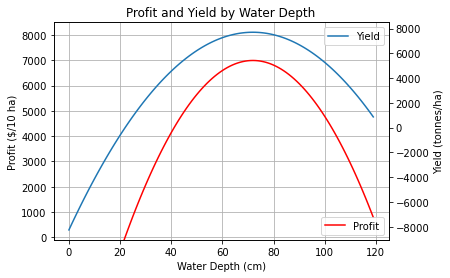

In [4]:
water = np.array(range(120))


# From Dinar et. al 1991 "Production functions relating crop yield, water quality and quantity, soil salinity and drainage volume"

y1 = (-3.350 + 0.2064*water - 0.0014*water*water + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water 
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc
               -0.071 * water * salt_conc_water + 0.033 * water * salt_conc 
               -2.754 * salt_conc_water * salt_conc)

p1 = (y1*price*10 )

fig, ax = plt.subplots()

ax.plot(water,p1, label = 'Profit', color = 'red') # profit is red line
ax.set_title('Profit and Yield by Water Depth')
ax.set_xlabel('Water Depth (cm)')
ax.set_ylabel('Profit ($/10 ha)')
ax.set_ylim([-100,7200])
ax.grid(True)
ax.legend(loc = 'lower right')

ax2 = ax.twinx()
ax2.plot(water,y1*lb_tonne, label = 'Yield') # yield is blue line
ax2.set_ylabel('Yield (tonnes/ha)')
ax.set_ylim([-100,8500])
ax2.legend()
plt.show()










In [5]:
run = list(range(1000))
run = [x+1 for x in run]
run_c0 = list(range(4000))
run_c0 = [x+1 for x in run_c0]
years = 25
year = list(range(years))
year = [x+1 for x in year]
samples_c0 = len(run_c0)
samples = len(run)

len(run_c0)
len(year)


4000

25

In [6]:
# To help get tight bounds on variables later on

maxrev  = max(p1*10*ha)
minrev  = 0

#Water peaks profit and yield at 73

print('max irrigation water')
max_irrigation_water
print('cost cm / year capacity alt water')
cost_alt_water
print('cost irrigation water / cm')
cost_irrigation_water
print('irrigation water elc need per cm')
irrigation_water_elc
print('alt water elc need per cm')
alt_water_elc



max irrigation water


7.62

cost cm / year capacity alt water


28950.375546080984

cost irrigation water / cm


1361.9960629921259

irrigation water elc need per cm


5283.425941929134

alt water elc need per cm


33021.412137057094

Another useful bound to speed up computational time. The max price is as good as it gets and since the above code doesn't have any cost max price is max rev.

This code defines the charts that are used in the other Stochastic programs.

Defines the stochastic model. This model is simply a weighted average. Takes each possible precipatation and its corresponding yield and profit and averages them equally.

Variabels

alt_water; irrigation_water

water

crop_yield, profit

Objective functions are all profit and correspond to the different precipation scenarios. Need to change this to climaate scenarios.

Water is function of precipitation, alternative water and irrigation water.

Crop yield is function of saliniatity, soil, and water.


Showing all the results for each precipation scenario. Need to change this to climate scenario.

Showing results of Profit Expected Value for CVaR 95%.

The second model where the CVaR is 75%. Instead of a weighted average model which Takes each possible precipatation and its corresponding yield and profit and averages them equally. This model uses the CVaR method.


In [7]:
m = gp.Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions, pick what climate you are in which automatically picks how much alternative water to invest in

alt_water_cap = m.addVar(name = 'alt_water_cap', lb = 0) # cm of depth
alt_elc_cap = m.addVar(name = 'alt_elc_cap', lb = 0) # kW of depth


#Second Stage Decision Variables Operational Decisions, Pick how much water to use and how much irrigation water to buy

# Change these variables to be a function of option, climate, and season
water = m.addVars(run_c0, year, lb = 0, name = 'water') # water used for crop, cm of depth
irrigation_water = m.addVars(run_c0, year, lb = 0, ub = max_irrigation_water, name = 'irrigation_water') # cm of depth
alt_water = m.addVars(run_c0, year, lb = 0, name = 'alt_water') # alt_water used for crop, cm of depth
alt_elc = m.addVars(run_c0, year, lb = 0, name = 'alt_elc') # alt_elc to power water, kWh
utility_elc = m.addVars(run_c0, year, lb = 0, name = 'util_elc') # util_elc to power water, kWh
elc = m.addVars(run_c0, year, lb = 0, name = 'elc') # total elc to power water, kWh

#Functions of the Above, also functions of option, climate, and season, 
crop_yield = m.addVars(run_c0, year, lb = 0, name = 'yield') # tonne/ha
profit = m.addVars(run_c0, obj = 1/samples_c0, name = 'profit') # $



# Objective



m.addConstrs( (profit[r] == crop_yield.sum(r,'*') * ha * price +
              -alt_water_cap * cost_alt_water  +
              -irrigation_water.sum(r,'*') * cost_irrigation_water +
              -alt_elc_cap * cost_alt_elc +
              -utility_elc.sum(r,'*') * cost_utility_elc
              for r in run_c0)
            ,name = 'profit_constr')

# Water Equations

m.addConstrs( (alt_water[r,y] <= alt_water_cap
               for r in run_c0 for y in year)
             ,name = 'water_cap' )
 

m.addConstrs( (rain_c0_dict[r,y] + alt_water[r,y] + irrigation_water[r,y] >= water[r,y]
              for r in run_c0 for y in year)
             ,name = 'water' )
             
             
#Energy for Alt Water Equations    

m.addConstrs( (alt_water[r,y] * alt_water_elc + irrigation_water[r,y] * irrigation_water_elc <= elc[r,y]
               for r in run_c0 for y in year)
             ,name = 'elc_water' )

# Energy Capacity and Balance Equations

m.addConstrs( (alt_elc[r,y] <= alt_elc_cap * cf_solar * hrs_month * gs_months
               for r in run_c0 for y in year)
             ,name = 'elc_cap' )




m.addConstrs( (alt_elc[r,y] + utility_elc[r,y] >= elc[r,y]
               for r in run_c0 for y in year)
             ,name = 'elc_balance' )





for r in run_c0:
    for y in year :
            m.addQConstr( (crop_yield[r,y] <= -3.350 + 0.2064*water[r,y]  - 0.0014*water[r,y]*water[r,y]  + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[r,y]  * salt_conc_water + 0.033 * water[r,y]  * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();




Academic license - for non-commercial use only - expires 2021-06-29
Using license file C:\Users\Jones\gurobi.lic


In [8]:
m.optimize()
obj = m.getObjective()
alt_water_c0 = alt_water_cap.X
alt_elc_c0 = alt_elc_cap.X
print('Objective Function')
print(obj.getValue())
print('Alt Water Investment')
alt_water_c0
print('Alt ELC Investment')
alt_elc_c0


Gurobi Optimizer version 9.1.1 build v9.1.1rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 504000 rows, 704002 columns and 1612000 nonzeros
Model fingerprint: 0x1bdb9eb4
Model has 100000 quadratic constraints
Coefficient statistics:
  Matrix range     [8e-02, 4e+04]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [3e-04, 3e-04]
  Bounds range     [8e+00, 8e+00]
  RHS range        [9e+00, 1e+02]
  QRHS range       [4e+00, 4e+00]
Presolve removed 200000 rows and 200000 columns
Presolve time: 1.30s
Presolved: 604000 rows, 704002 columns, 1812000 nonzeros
Presolved model has 100000 second-order cone constraints
Ordering time: 0.12s

Barrier statistics:
 Dense cols : 2
 AA' NZ     : 1.408e+06
 Factor NZ  : 4.056e+06 (roughly 600 MBytes of memory)
 Factor Ops : 2.987e+07 (less than 1 second per iteration)
 Threads    : 4

                  Objective                Residual
Iter       Primal  

5.445670584862284

Alt ELC Investment


94.41230096593276

In [9]:
# Writing Solutions to Dictionary

profit_dict = m.getAttr('x', profit)
crop_yield_dict = m.getAttr('x', crop_yield)
water_dict = m.getAttr('x', water)
irrigation_water_dict = m.getAttr('x', irrigation_water)
alt_water_dict = m.getAttr('x', alt_water)
elc_dict = m.getAttr('x', elc)
utility_elc_dict = m.getAttr('x', utility_elc)
alt_elc_dict = m.getAttr('x', alt_elc)



In [10]:
#Changing Tuple Dictionary to Dataframe

profit_df = pd.Series(profit_dict).reset_index()
profit_df.columns = ['run', 'profit'] 

crop_yield_df = pd.Series(crop_yield_dict).reset_index()
crop_yield_df.columns = ['run', 'year', 'crop_yield'] 

rain_df = pd.Series(rain_c0_dict).reset_index()
rain_df.columns = ['run', 'year', 'water depth'] 

water_df = pd.Series(water_dict).reset_index()
water_df.columns = ['run', 'year', 'water_depth'] 

irrigation_water_df = pd.Series(irrigation_water_dict).reset_index()
irrigation_water_df.columns = ['run', 'year', 'water_depth'] 

alt_water_df = pd.Series(alt_water_dict).reset_index()
alt_water_df.columns = ['run', 'year', 'water_depth'] 

alt_elc_df = pd.Series(alt_elc_dict).reset_index()
alt_elc_df.columns = ['run', 'year', 'elc_prod'] 

elc_df = pd.Series(elc_dict).reset_index()
elc_df.columns = ['run', 'year', 'elc_prod'] 

utility_elc_df = pd.Series(utility_elc_dict).reset_index()
utility_elc_df.columns = ['run', 'year', 'elc_prod'] 


In [11]:
# Calculating Confidence Interval

profit_array = np.array(list(profit_dict.values()))

crop_yield_array = np.fromiter(crop_yield_dict.values(), dtype=float)


# rename profit array
a = profit_array * 1.0

# number of samples in array
n = len(a)
# calculate mean and sample error
m, se = np.mean(a), scs.sem(a)
# calculate t distrb
t = scs.t.ppf((1 + 0.95) / 2., n-1)
# calculate step size
h = se * t
# print sample size, mean, standard error, t value, step size, lower interval, and higher interval
n, m, se, t, h, m-h, m+h

# rename crop yield array
b = crop_yield_array * 1.0

# number of samples in array
n = len(b)
# calculate mean and sample error
m, se = np.mean(b), scs.sem(b)
# calculate t distrb
t = scs.t.ppf((1 + 0.95) / 2., n-1)
# calculate step size
h = se * t
# print sample size, mean, standard error, t value, step size, lower interval, and higher interval
n, m, se, t, h, m-h, m+h

(4000,
 2246937.9614990954,
 9746.994291010631,
 1.9605573771860274,
 19109.541562630984,
 2227828.4199364646,
 2266047.503061726)

(100000,
 2.6742899615718634,
 0.003521943939411115,
 1.9599877077718446,
 0.006902966828707332,
 2.667386994743156,
 2.681192928400571)

Climate Run

In [12]:
m = gp.Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions, pick what climate you are in which automatically picks how much alternative water to invest in

alt_water_cap = m.addVar(name = 'alt_water_cap', lb = 0) # cm of depth
alt_elc_cap = m.addVar(name = 'alt_elc_cap', lb = 0) # kW of depth


#Second Stage Decision Variables Operational Decisions, Pick how much water to use and how much irrigation water to buy

# Change these variables to be a function of option, climate, and season
water = m.addVars(run, year, lb = 0, name = 'water') # water used for crop, cm of depth
irrigation_water = m.addVars(run, year, lb = 0, ub = max_irrigation_water, name = 'irrigation_water') # cm of depth
alt_water = m.addVars(run, year, lb = 0, name = 'alt_water') # alt_water used for crop, cm of depth
alt_elc = m.addVars(run, year, lb = 0, name = 'alt_elc') # alt_elc to power water, kWh
utility_elc = m.addVars(run, year, lb = 0, name = 'util_elc') # util_elc to power water, kWh
elc = m.addVars(run, year, lb = 0, name = 'elc') # total elc to power water, kWh

#Functions of the Above, also functions of option, climate, and season, 
crop_yield = m.addVars(run, year, lb = 0, name = 'yield') # tonne/ha
profit = m.addVars(run, obj = 1/samples, name = 'profit') # $



#Maybe add a new profit variable that is the sum of the profit based on climate for easy coefficients



# Objective


m.addConstrs( (profit[r] == crop_yield.sum(r,'*') * ha * price +
              -alt_water_cap * cost_alt_water  +
              -irrigation_water.sum(r,'*') * cost_irrigation_water +
              -alt_elc_cap * cost_alt_elc +
              -utility_elc.sum(r,'*') * cost_utility_elc
              for r in run)
            ,name = 'profit_constr')

# Water Equations

m.addConstrs( (alt_water[r,y] <= alt_water_cap
               for r in run for y in year)
             ,name = 'water_cap' )
 

m.addConstrs( (rain_dict[r,y] + alt_water[r,y] + irrigation_water[r,y] >= water[r,y]
              for r in run for y in year)
             ,name = 'water' )
             
             
#Energy for Alt Water Equations    

m.addConstrs( (alt_water[r,y] * alt_water_elc + irrigation_water[r,y] * irrigation_water_elc <= elc[r,y]
               for r in run for y in year)
             ,name = 'elc_water' )

# Energy Capacity and Balance Equations

m.addConstrs( (alt_elc[r,y] <= alt_elc_cap * cf_solar * hrs_month * gs_months
               for r in run for y in year)
             ,name = 'elc_cap' )




m.addConstrs( (alt_elc[r,y] + utility_elc[r,y] >= elc[r,y]
               for r in run for y in year)
             ,name = 'elc_balance' )





for r in run:
    for y in year :
            m.addQConstr( (crop_yield[r,y] <= -3.350 + 0.2064*water[r,y]  - 0.0014*water[r,y]*water[r,y]  + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[r,y]  * salt_conc_water + 0.033 * water[r,y]  * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();





In [13]:
m.optimize()
obj = m.getObjective()
alt_water_c1 = alt_water_cap.X
alt_elc_c1 = alt_elc_cap.X
print('Objective Function')
print(obj.getValue())
print('Alt Water Investment')
alt_water_c1
print('Alt ELC Investment')
alt_elc_c1

Gurobi Optimizer version 9.1.1 build v9.1.1rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 126000 rows, 176002 columns and 403000 nonzeros
Model fingerprint: 0x1b8f0ef5
Model has 25000 quadratic constraints
Coefficient statistics:
  Matrix range     [8e-02, 4e+04]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [1e-03, 1e-03]
  Bounds range     [8e+00, 8e+00]
  RHS range        [9e+00, 8e+01]
  QRHS range       [4e+00, 4e+00]
Presolve removed 50000 rows and 50000 columns
Presolve time: 0.26s
Presolved: 151000 rows, 176002 columns, 453000 nonzeros
Presolved model has 25000 second-order cone constraints
Ordering time: 0.02s

Barrier statistics:
 Dense cols : 2
 AA' NZ     : 3.520e+05
 Factor NZ  : 1.014e+06 (roughly 140 MBytes of memory)
 Factor Ops : 7.468e+06 (less than 1 second per iteration)
 Threads    : 4

                  Objective                Residual
Iter       Primal        

15.826426588874952

Alt ELC Investment


289.5424671757024

In [14]:
# Writing Solutions to Dictionary

profit_dict = m.getAttr('x', profit)
crop_yield_dict = m.getAttr('x', crop_yield)
water_dict = m.getAttr('x', water)
irrigation_water_dict = m.getAttr('x', irrigation_water)
alt_water_dict = m.getAttr('x', alt_water)
elc_dict = m.getAttr('x', elc)
utility_elc_dict = m.getAttr('x', utility_elc)
alt_elc_dict = m.getAttr('x', alt_elc)

In [15]:
#Changing Tuple Dictionary to Dataframe

profit_df_c1 = pd.Series(profit_dict).reset_index()
profit_df_c1.columns = ['run', 'profit'] 

crop_yield_df_c1 = pd.Series(crop_yield_dict).reset_index()
crop_yield_df_c1.columns = ['run', 'year', 'crop_yield'] 

rain_df_c1 = pd.Series(rain_c0_dict).reset_index()
rain_df_c1.columns = ['run', 'year', 'water depth'] 

water_df_c1 = pd.Series(water_dict).reset_index()
water_df_c1.columns = ['run', 'year', 'water_depth'] 

irrigation_water_df_c1 = pd.Series(irrigation_water_dict).reset_index()
irrigation_water_df_c1.columns = ['run', 'year', 'water_depth'] 

alt_water_df_c1 = pd.Series(alt_water_dict).reset_index()
alt_water_df_c1.columns = ['run', 'year', 'water_depth'] 

alt_elc_df_c1 = pd.Series(alt_elc_dict).reset_index()
alt_elc_df_c1.columns = ['run', 'year', 'elc_prod'] 

elc_df_c1 = pd.Series(elc_dict).reset_index()
elc_df_c1.columns = ['run', 'year', 'elc_prod'] 

utility_elc_df_c1 = pd.Series(utility_elc_dict).reset_index()
utility_elc_df_c1.columns = ['run', 'year', 'elc_prod'] 



In [19]:
m = gp.Model()

#m.params.NonConvex = 2 # Says its non convex but it is (FIXED quadratic constraints can't be equality)

# Set to maximize
m.ModelSense = -1

# Add variables

#First Stage Decision Variables Strategic Investment Decisions, pick what climate you are in which automatically picks how much alternative water to invest in

alt_water_cap = alt_water_c0
alt_elc_cap = alt_elc_c0
#alt_water_cap = m.addVar(name = 'alt_water_cap', lb = 0) # cm of depth
#alt_elc_cap = m.addVar(name = 'alt_elc_cap', lb = 0) # kW of depth


#Second Stage Decision Variables Operational Decisions, Pick how much water to use and how much irrigation water to buy

# Change these variables to be a function of option, climate, and season
water = m.addVars(run, year, lb = 0, name = 'water') # water used for crop, cm of depth
irrigation_water = m.addVars(run, year, lb = 0, ub = max_irrigation_water, name = 'irrigation_water') # cm of depth
alt_water = m.addVars(run, year, lb = 0, name = 'alt_water') # alt_water used for crop, cm of depth
alt_elc = m.addVars(run, year, lb = 0, name = 'alt_elc') # alt_elc to power water, kWh
utility_elc = m.addVars(run, year, lb = 0, name = 'util_elc') # util_elc to power water, kWh
elc = m.addVars(run, year, lb = 0, name = 'elc') # total elc to power water, kWh

#Functions of the Above, also functions of option, climate, and season, 
crop_yield = m.addVars(run, year, lb = 0, name = 'yield') # tonne/ha
profit = m.addVars(run, obj = 1/samples, name = 'profit') # $



#Maybe add a new profit variable that is the sum of the profit based on climate for easy coefficients



# Objective


m.addConstrs( (profit[r] == crop_yield.sum(r,'*') * ha * price +
              -alt_water_cap * cost_alt_water  +
              -irrigation_water.sum(r,'*') * cost_irrigation_water +
              -alt_elc_cap * cost_alt_elc +
              -utility_elc.sum(r,'*') * cost_utility_elc
              for r in run)
            ,name = 'profit_constr')

# Water Equations

m.addConstrs( (alt_water[r,y] <= alt_water_cap
               for r in run for y in year)
             ,name = 'water_cap' )
 

m.addConstrs( (rain_dict[r,y] + alt_water[r,y] + irrigation_water[r,y] >= water[r,y]
              for r in run for y in year)
             ,name = 'water' )
             
             
#Energy for Alt Water Equations    

m.addConstrs( (alt_water[r,y] * alt_water_elc + irrigation_water[r,y] * irrigation_water_elc <= elc[r,y]
               for r in run for y in year)
             ,name = 'elc_water' )

# Energy Capacity and Balance Equations

m.addConstrs( (alt_elc[r,y] <= alt_elc_cap * cf_solar * hrs_month * gs_months
               for r in run for y in year)
             ,name = 'elc_cap' )




m.addConstrs( (alt_elc[r,y] + utility_elc[r,y] >= elc[r,y]
               for r in run for y in year)
             ,name = 'elc_balance' )





for r in run:
    for y in year :
            m.addQConstr( (crop_yield[r,y] <= -3.350 + 0.2064*water[r,y]  - 0.0014*water[r,y]*water[r,y]  + 
               3.555 * salt_conc_water + 2.326 * salt_conc_water*salt_conc_water +
               -2.031 * salt_conc + 0.823 * salt_conc*salt_conc +
               -0.071 * water[r,y]  * salt_conc_water + 0.033 * water[r,y]  * salt_conc +
               -2.754 * salt_conc_water * salt_conc
               )
               , name = 'crop_yield' )


m.update();



In [20]:
m.optimize()
obj = m.getObjective()
print('Objective Function')
print(obj.getValue())



Gurobi Optimizer version 9.1.1 build v9.1.1rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 126000 rows, 176000 columns and 351000 nonzeros
Model fingerprint: 0xf9fe12d4
Model has 25000 quadratic constraints
Coefficient statistics:
  Matrix range     [8e-02, 4e+04]
  QMatrix range    [1e-03, 1e-03]
  QLMatrix range   [2e-01, 1e+00]
  Objective range  [1e-03, 1e-03]
  Bounds range     [8e+00, 8e+00]
  RHS range        [5e+00, 3e+05]
  QRHS range       [4e+00, 4e+00]
Presolve removed 75000 rows and 50000 columns
Presolve time: 0.21s
Presolved: 130933 rows, 176000 columns, 380933 nonzeros
Presolved model has 25000 second-order cone constraints
Ordering time: 0.02s

Barrier statistics:
 AA' NZ     : 2.697e+05
 Factor NZ  : 6.311e+05 (roughly 130 MBytes of memory)
 Factor Ops : 4.223e+06 (less than 1 second per iteration)
 Threads    : 4

                  Objective                Residual
Iter       Primal          Dual         P

In [21]:
# Writing Solution Variables to Dictionary

profit_dict = m.getAttr('x', profit)
crop_yield_dict = m.getAttr('x', crop_yield)
water_dict = m.getAttr('x', water)
irrigation_water_dict = m.getAttr('x', irrigation_water)
alt_water_dict = m.getAttr('x', alt_water)
elc_dict = m.getAttr('x', elc)
utility_elc_dict = m.getAttr('x', utility_elc)
alt_elc_dict = m.getAttr('x', alt_elc)

In [22]:
# Writing Dictionaries to Dataframes

profit_df_c01 = pd.Series(profit_dict).reset_index()
profit_df_c01.columns = ['run', 'profit'] 

crop_yield_df_c01 = pd.Series(crop_yield_dict).reset_index()
crop_yield_df_c01.columns = ['run', 'year', 'crop_yield'] 

water_df_c01 = pd.Series(water_dict).reset_index()
water_df_c01.columns = ['run', 'year', 'water_depth'] 

irrigation_water_df_c01 = pd.Series(irrigation_water_dict).reset_index()
irrigation_water_df_c01.columns = ['run', 'year', 'water_depth'] 

alt_water_df_c01 = pd.Series(alt_water_dict).reset_index()
alt_water_df_c01.columns = ['run', 'year', 'water_depth'] 

alt_elc_df_c01 = pd.Series(alt_elc_dict).reset_index()
alt_elc_df_c01.columns = ['run', 'year', 'elc_prod'] 

elc_df_c01 = pd.Series(elc_dict).reset_index()
elc_df_c01.columns = ['run', 'year', 'elc_prod'] 

utility_elc_df_c01 = pd.Series(utility_elc_dict).reset_index()
utility_elc_df_c01.columns = ['run', 'year', 'elc_prod'] 

In [23]:
profit_df
crop_yield_df
alt_water_c0
alt_elc_c0

profit_df_c1
crop_yield_df_c1
alt_water_c1
alt_elc_c1

profit_df_c01
crop_yield_df_c01



,run,profit
0,1,1.579083e+06
1,2,1.785174e+06
2,3,1.076315e+06
3,4,1.322596e+06
4,5,1.333067e+06
...,...,...
3995,3996,3.067854e+06
3996,3997,2.915551e+06
3997,3998,2.977267e+06
3998,3999,3.067854e+06


,run,year,crop_yield
0,1,1,2.045271e+00
1,1,2,2.045271e+00
2,1,3,2.078070e-09
3,1,4,3.496207e+00
4,1,5,2.045271e+00
...,...,...,...
99995,4000,21,3.496207e+00
99996,4000,22,3.279552e+00
99997,4000,23,2.045271e+00
99998,4000,24,3.496207e+00


5.445670584862284

94.41230096593276

,run,profit
0,1,1.702682e+06
1,2,1.860700e+06
2,3,1.348770e+06
3,4,1.555877e+06
4,5,1.579995e+06
...,...,...
995,996,1.861127e+06
996,997,1.420677e+06
997,998,1.848650e+06
998,999,1.825387e+06


,run,year,crop_yield
0,1,1,2.830129
1,1,2,2.830129
2,1,3,1.301653
3,1,4,3.496207
4,1,5,2.830129
...,...,...,...
24995,1000,21,2.830129
24996,1000,22,1.301653
24997,1000,23,3.485526
24998,1000,24,2.830129


15.826426588874952

289.5424671757024

,run,profit
0,1,1.579083e+06
1,2,1.785174e+06
2,3,1.076315e+06
3,4,1.322596e+06
4,5,1.333067e+06
...,...,...
995,996,1.794797e+06
996,997,1.170877e+06
997,998,1.743552e+06
998,999,1.752328e+06


,run,year,crop_yield
0,1,1,2.045271e+00
1,1,2,2.045271e+00
2,1,3,1.273079e-09
3,1,4,3.496207e+00
4,1,5,2.045271e+00
...,...,...,...
24995,1000,21,2.045271e+00
24996,1000,22,1.263867e-09
24997,1000,23,3.279551e+00
24998,1000,24,2.045271e+00
